In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 13
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']

# import seaborn as sns

# colors = sns.color_palette("Set2")          # pastel but distinct
# or
# colors = sns.color_palette("Paired")        # matched pairs
# or
# colors = sns.color_palette("deep")          # Seaborn default
# or
# colors = sns.color_palette("colorblind")    # colorblind-safe



from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# modelA = 'deepseek'
# modelA = 'llama8b'
modelA = 'qwen7b'
modelB = modelA
languages = [
            'english',
            ]

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=float)
layers /= depths[modelB]

# layers = np.arange(1,depths[modelB] + 1) / depths[modelA]

batch_shuffle = 0
centers_var = 'syn'
n_files = 21
batch_size = 100
avg_flags = [0,1]
Nbits = 0
match_vars = ['matching']
data_var ='syn'
zero_activations_list = [0]
center_B_flags = [0,1,-1]
center_A_flags = [0,1,-1]

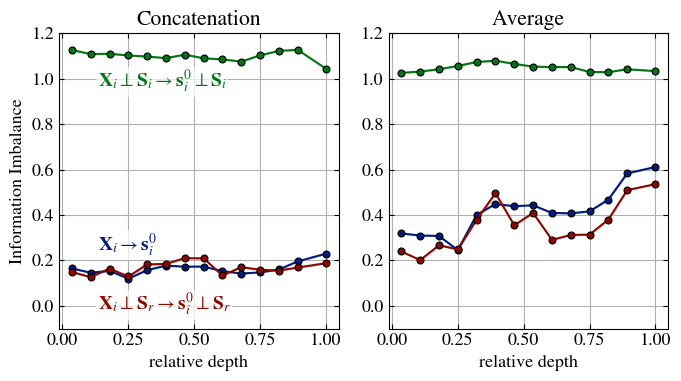

In [8]:
precision = 32
fig,ax = plt.subplots(1,2,figsize=(7,4))


for avg_id,avg_tokens in enumerate(avg_flags):
  if avg_tokens: 
    min_token_length = -1
  else: 
    min_token_length = 6
  n_tokens = min_token_length
  # avg_id += 1
  title = ' '
  label = None
  plot_id = 0

  for match_id,match_var in enumerate(match_vars):
    for removal_method in [None,'projection']:
      _removal_method = 'projection' if removal_method == 'projection' else 'center'
      for zero_id,zero_activations in enumerate(zero_activations_list):
        for center_A_id,center_A_flag in enumerate(center_A_flags):
          for center_B_id,center_B_flag in enumerate(center_B_flags):
            if center_A_flag != center_B_flag: 
              continue
            if center_A_flag != 0 and removal_method == None:
              continue
            if center_A_flag == 0 and removal_method != None:
              continue

            if match_var == 'mismatching' and center_A_flag != 0:
              continue
            output_folder0 = makefolder(base=f'./results/',
                                        global_centering=0,
                                        spaces='AB',
                                        similarity_fn='normalized_L2_distance',
                                        precision=precision,
                                        language='english',
                                        data_var=data_var,
                                        modelA=modelA,
                                        modelB=modelB,
                                        match_var=match_var,
                                        n_files=n_files,
                                        min_token_length=min_token_length,
                                        )
            II_folder = makefolder(base=output_folder0,
                                              centers=centers_var,
                                              Nbits=Nbits,
                                              n_tokens=n_tokens,
                                              avg_tokens=avg_tokens,
                                              batch_shuffle=batch_shuffle,
                                              zero_activations=zero_activations,
                                              center_A_flag=center_A_flag,
                                              center_B_flag=center_B_flag,
                                              removal_method=removal_method,
                                              )
            inf_imb = np.load(II_folder + "II.npy")
            std = np.load(II_folder + "II_jack_std.npy")

            color = colors[plot_id] 
            linestyle = '-'
            if avg_tokens:
              title = f'Average'
            else:
              title = f'Concatenation'

            if avg_id == 0:
              label = ''
              if center_A_flag == 0:
                if match_var == 'mismatching':
                  label += 'length-matching control'
                elif match_var == 'matching':
                  label += r'$\mathbf{X}_i \rightarrow \mathbf{s}^{0}_i$'

              if removal_method == 'projection':    
                if center_A_flag == -1:
                  label +=  r'$\mathbf{X}_i \perp \mathbf{S}_r \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_r$'
                if center_A_flag == 1:
                  label += r'$\mathbf{X}_i \perp \mathbf{S}_i \rightarrow \mathbf{s}^{0}_i \perp \mathbf{S}_i$'
              elif removal_method == 'subtraction':
                if center_A_flag == -1:
                  label +=  r'$\mathbf{X}_i - S_j \rightarrow \mathbf{s}^{0}_i - S_j \quad (j \neq i)$'
                if center_A_flag == 1:
                  label += r'$\mathbf{X}_i - \mathbf{S}_i \rightarrow \mathbf{s}^{0}_i - \mathbf{S}_i$'

            for II_index in range(1):
              ax[avg_id].plot(
                  layers,
                  inf_imb[II_index].diagonal(),
                  label=label,
                  linestyle=_linestyles[II_index],
                  color=color,
                  marker='o',                # circular marker
                  markersize=5,              # tweakable size
                  markerfacecolor=color,     # fill same as line
                  markeredgecolor='black',   # cute black border
                  markeredgewidth=0.8,       # adjust border thickness
              )

              ax[avg_id].fill_between(layers,
                              inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                              inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                              alpha=0.2,
                              color=color,
                              )
            plot_id += 1
  ax[0].set_ylabel('Information Imbalance')
  ax[avg_id].set_xlabel('relative depth')
  ax[avg_id].set_title(title)

  ax[avg_id].grid()

  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  
  ax[avg_id].set_ylim(-.1,1.2)
    
enum_line = 0
for line in ax[0].lines:
    if enum_line == 0:
      _va = 'bottom' 
      _aux_y = 10
    else:
      _va = 'top'
      _aux_y = -10 if enum_line < 3 else -25
    label = line.get_label()
    if not label:
        continue
    xdata, ydata = line.get_xdata(), line.get_ydata()
    ax[0].annotate(
        label,
        xy=(xdata[1], ydata[1]),
        xytext=(5, _aux_y),  # offset in points
        textcoords='offset points',
        fontsize=14,
        color=line.get_color(),
        ha='left',
        va=_va,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
    )
    enum_line += 1

os.makedirs('results/figs', exist_ok=True)
fig.savefig(f'results/figs/syntax_similarity_{modelA}_{removal_method}.pdf', bbox_inches='tight')
plt.show()